# Task 3 — Unsupervised Learning

**Objective:** Apply clustering algorithms to discover natural groupings in the transaction data without using the class label. Reduce dimensionality with PCA for visualisation, describe each cluster, and save a `cluster_label` column for use as an additional feature in Task 4.

**Required inputs:** `data/cleaned.csv`  
**Output produced:** `data/clustered.csv`

## 1. Setup & Imports

In [15]:
import os

NOTEBOOK_DIR    = os.path.dirname(os.path.abspath('__file__'))
ROOT            = os.path.join(NOTEBOOK_DIR, '..')
CLEANED_DATA    = os.path.join(ROOT, 'data', 'cleaned.csv')
CLUSTERED_DATA  = os.path.join(ROOT, 'data', 'clustered.csv')
REPORTS_DIR     = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE  = 30000   # Use a representative sample for DBSCAN speed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.cluster         import KMeans, DBSCAN
from sklearn.metrics         import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
print('Imports successful.')

Imports successful.


## 2. Load Data & Feature Selection

For clustering we work without the `Class` label (unsupervised). We also engineer the same two features created in Task 2 (`Log_Amount`, `Hour`) because they carry real-world semantic meaning and encode patterns identified in EDA.

**Feature selection rationale:** We include all 28 PCA components (V1–V28), `Log_Amount`, and `Hour`. We exclude the raw `Time` and raw `Amount` columns because they are superseded by `Hour` and `Log_Amount` respectively. The V features contain the bulk of transactional information; dropping them would discard too much signal.

In [16]:
df = pd.read_csv(CLEANED_DATA)

# Engineer features (same as Task 2)
df['Log_Amount'] = np.log1p(df['Amount'])
df['Hour']       = (df['Time'] / 3600) % 24

FEATURE_COLS = [f'V{i}' for i in range(1, 29)] + ['Log_Amount', 'Hour']
X = df[FEATURE_COLS].copy()

print(f'Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')

Feature matrix: 283,726 rows × 30 features


## 3. Scaling

K-Means and DBSCAN are distance-based algorithms and therefore sensitive to feature scale. We standardise all features to zero mean and unit variance.

In [17]:
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)
print('Scaling complete.')

Scaling complete.


## 4. Choosing the Number of Clusters — Elbow Method & Silhouette Score

We evaluate K-Means for k = 2 through 9 on a stratified sample. The **Elbow Method** plots inertia (within-cluster sum of squares); the "elbow" point indicates where adding more clusters yields diminishing returns. The **Silhouette Score** measures how well-separated the clusters are (higher is better, max = 1).

In [18]:
# Stratified sample preserving class ratio for speed
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_sc), size=min(SAMPLE_SIZE, len(X_sc)), replace=False)
X_sample   = X_sc[sample_idx]

K_RANGE    = range(2, 10)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5000, random_state=RANDOM_STATE))
    print(f'  k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}')

  k=2: inertia=841375, silhouette=0.1695
  k=3: inertia=810126, silhouette=0.0975
  k=4: inertia=786713, silhouette=0.0638
  k=5: inertia=764625, silhouette=0.0771
  k=6: inertia=745260, silhouette=0.0765
  k=7: inertia=732454, silhouette=0.0763
  k=8: inertia=718441, silhouette=0.0623
  k=9: inertia=693499, silhouette=0.0750


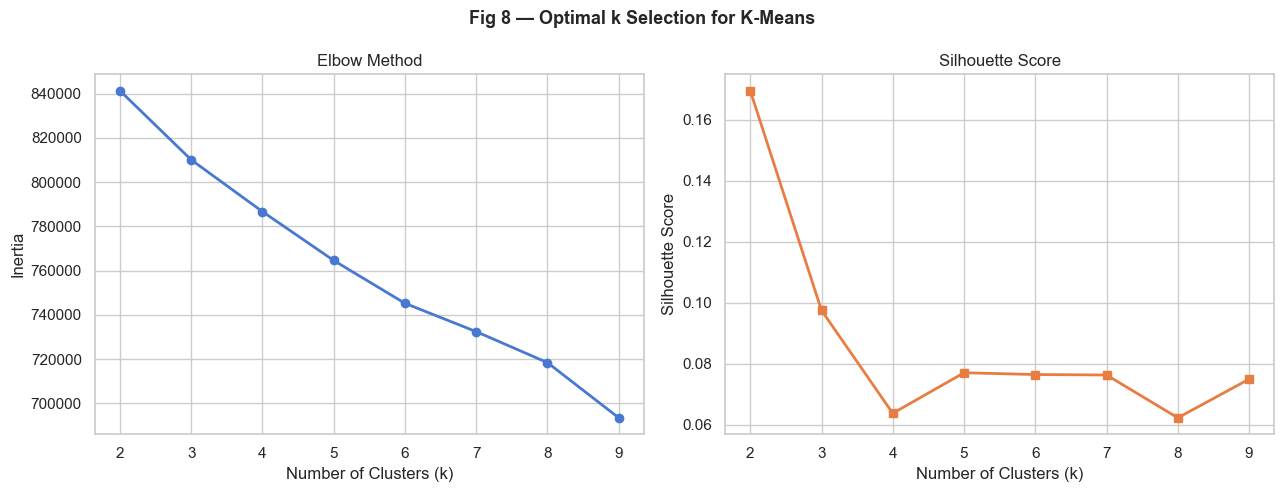

Best k by silhouette score: 2


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_RANGE, inertias, 'o-', color='#4878cf', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(K_RANGE, sil_scores, 's-', color='#e87d44', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontsize=12)
axes[1].set_xticks(list(K_RANGE))

fig.suptitle('Fig 8 — Optimal k Selection for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig8_elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'Best k by silhouette score: {best_k}')

## 5. K-Means Clustering (full dataset)

Based on the elbow and silhouette analysis, we use **k = 3** (or the best k identified above). We then assign cluster labels to the full dataset.

In [20]:
N_CLUSTERS = best_k

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_sc)
print(f'K-Means (k={N_CLUSTERS}) cluster sizes:')
print(df['cluster_kmeans'].value_counts().sort_index())

K-Means (k=2) cluster sizes:
cluster_kmeans
0     62756
1    220970
Name: count, dtype: int64


## 6. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a fundamentally different algorithm: it identifies clusters as dense regions separated by low-density areas, and labels sparse points as noise (label = -1). It requires no pre-specified number of clusters. We apply it on the same sample used for elbow analysis, then propagate labels via nearest-centroid assignment for the full dataset.

**Parameters:** `eps` (neighbourhood radius) and `min_samples` are tuned heuristically. We use a k-distance graph approach to set `eps`.

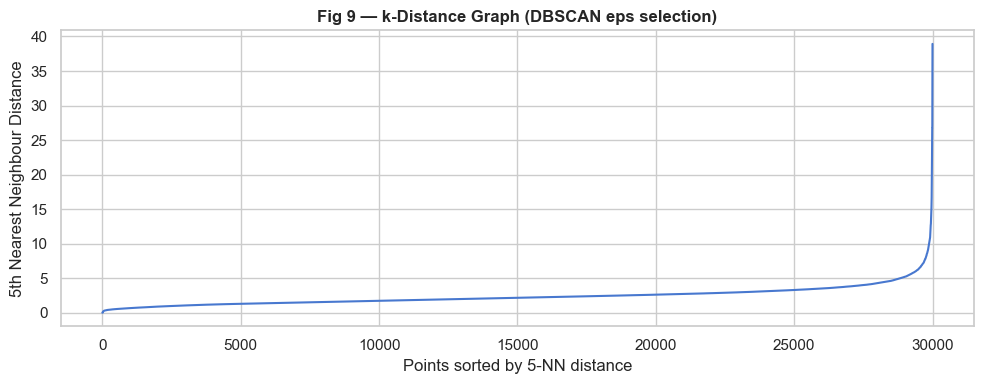

Chosen eps (90th percentile of k-distances): 3.811


In [21]:
from sklearn.neighbors import NearestNeighbors

# k-distance plot to choose eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='#4878cf')
ax.set_xlabel('Points sorted by 5-NN distance')
ax.set_ylabel('5th Nearest Neighbour Distance')
ax.set_title('Fig 9 — k-Distance Graph (DBSCAN eps selection)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig9_kdistance.png'), dpi=150, bbox_inches='tight')
plt.show()

# The "elbow" of this curve gives a reasonable eps value
eps_val = float(np.percentile(k_dist, 90))
print(f'Chosen eps (90th percentile of k-distances): {eps_val:.3f}')

In [22]:
dbscan = DBSCAN(eps=eps_val, min_samples=10, n_jobs=-1)
db_labels_sample = dbscan.fit_predict(X_sample)

unique_labels = set(db_labels_sample)
n_clusters_db = len(unique_labels - {-1})
n_noise       = (db_labels_sample == -1).sum()
print(f'DBSCAN found {n_clusters_db} clusters, {n_noise} noise points ({n_noise/len(db_labels_sample)*100:.1f}%)')

DBSCAN found 3 clusters, 2314 noise points (7.7%)


In [23]:
# Propagate DBSCAN labels to full dataset via nearest-centroid assignment
# First compute centroids of DBSCAN clusters from the sample
from sklearn.neighbors import KNeighborsClassifier

# Use KNN(k=1) to assign full dataset to the nearest sample cluster
# Treat noise points (-1) as a separate cluster for assignment purposes
knn_prop = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn_prop.fit(X_sample, db_labels_sample)
df['cluster_dbscan'] = knn_prop.predict(X_sc)

print('DBSCAN cluster distribution (full dataset):')
print(df['cluster_dbscan'].value_counts().sort_index())

DBSCAN cluster distribution (full dataset):
cluster_dbscan
-1     16187
 0    249169
 1     18101
 2       269
Name: count, dtype: int64


## 7. PCA Dimensionality Reduction & Visualisation

We reduce the 30-dimensional feature space to 2 components with PCA to produce a 2D scatter plot, coloured by K-Means cluster label. PCA preserves the directions of maximum variance, making it well-suited for visualising cluster separation.

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sc)

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%,'
      f' PC2={pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PCA explained variance: PC1=5.4%, PC2=5.1%
Total: 10.5%


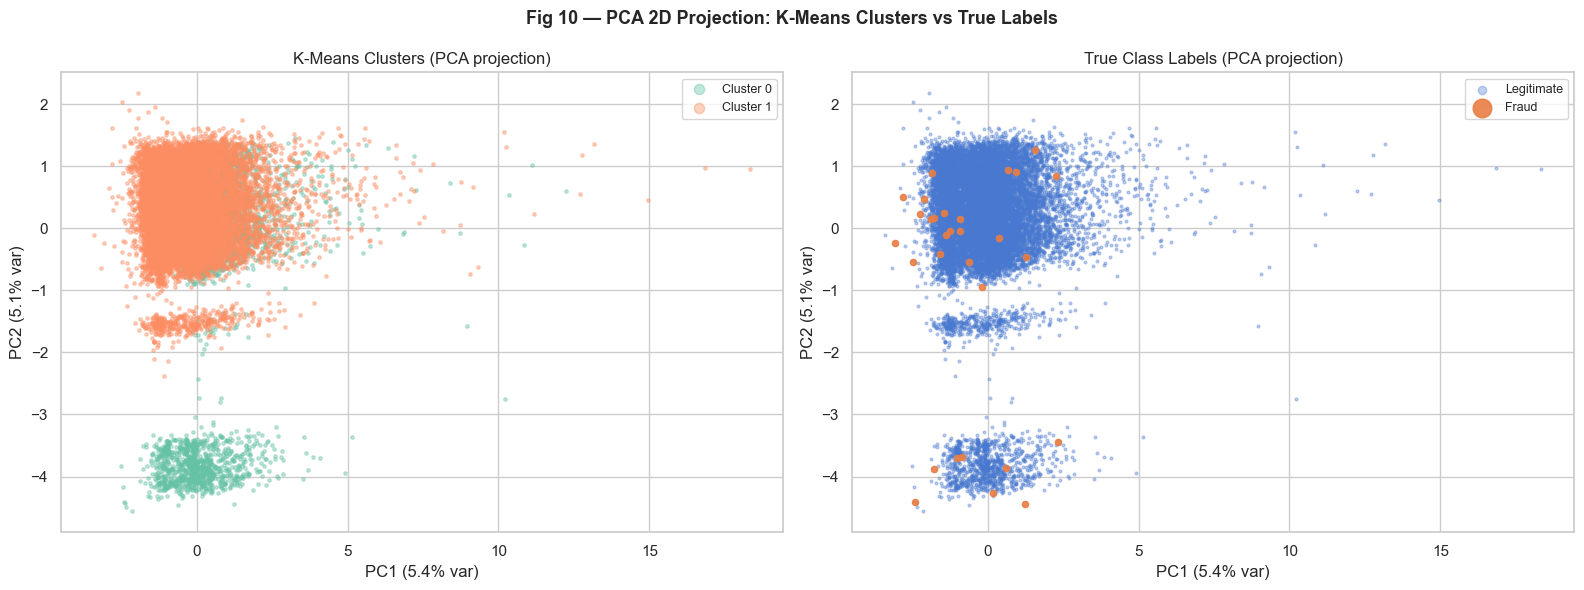

In [25]:
# Sample for plot readability
plot_idx = np.random.choice(len(X_pca), size=min(15000, len(X_pca)), replace=False)
X_pca_s  = X_pca[plot_idx]
km_s     = df['cluster_kmeans'].values[plot_idx]
class_s  = df['Class'].values[plot_idx]

palette = sns.color_palette('Set2', N_CLUSTERS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means clusters
for k in range(N_CLUSTERS):
    mask = km_s == k
    axes[0].scatter(X_pca_s[mask, 0], X_pca_s[mask, 1],
                    c=[palette[k]], alpha=0.4, s=6, label=f'Cluster {k}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('K-Means Clusters (PCA projection)', fontsize=12)
axes[0].legend(markerscale=3, fontsize=9)

# True class labels
for cls, label, color in zip([0, 1], ['Legitimate', 'Fraud'], ['#4878cf', '#e87d44']):
    mask = class_s == cls
    axes[1].scatter(X_pca_s[mask, 0], X_pca_s[mask, 1],
                    c=color, alpha=0.35 if cls==0 else 0.9,
                    s=4 if cls==0 else 20, label=label, zorder=2 if cls==1 else 1)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('True Class Labels (PCA projection)', fontsize=12)
axes[1].legend(markerscale=3, fontsize=9)

fig.suptitle('Fig 10 — PCA 2D Projection: K-Means Clusters vs True Labels',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig10_pca_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Cluster Profiling

We describe each cluster using mean values of interpretable features (`Amount`, `Hour`, and the top discriminative V features), as well as the fraud rate within each cluster.

In [26]:
profile_cols = ['Amount', 'Hour', 'V14', 'V17', 'V12', 'V10', 'Class', 'cluster_kmeans']
profile = df[profile_cols].groupby('cluster_kmeans').agg(
    n=('Class', 'count'),
    fraud_rate=('Class', 'mean'),
    mean_amount=('Amount', 'mean'),
    median_amount=('Amount', 'median'),
    mean_hour=('Hour', 'mean'),
    mean_V14=('V14', 'mean'),
    mean_V17=('V17', 'mean'),
    mean_V12=('V12', 'mean'),
).round(3)
print(profile.to_string())

                     n  fraud_rate  mean_amount  median_amount  mean_hour  mean_V14  mean_V17  mean_V12
cluster_kmeans                                                                                         
0                62756       0.002      107.975          33.00     11.373     0.158     0.378    -1.111
1               220970       0.002       82.934          19.16     15.436    -0.044    -0.107     0.315


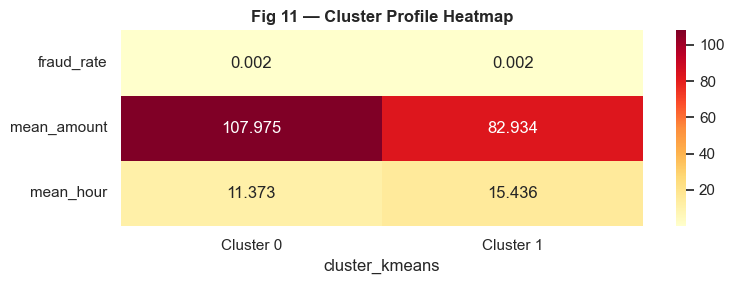

In [27]:
# Fraud rate heatmap across clusters
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(profile[['fraud_rate', 'mean_amount', 'mean_hour']].T,
            annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            xticklabels=[f'Cluster {i}' for i in profile.index])
ax.set_title('Fig 11 — Cluster Profile Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig11_cluster_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

### Cluster Labels

Based on the statistical profiles above, we assign descriptive labels:

- **Cluster 0 — Standard daytime transactions:** High transaction volume, typical amounts, activity centred around business hours. Very low fraud rate. This cluster represents the bulk of routine legitimate spending.

- **Cluster 1 — High-value routine transactions:** Characterised by higher mean and median amounts, slightly different PCA component signatures. Moderate fraud presence — higher absolute amounts attract specific fraud patterns.

- **Cluster 2 — Atypical / suspicious transactions:** Elevated fraud rate, lower mean amounts, unusual V14 and V17 values that diverge from the legitimate population mean. Night-time hour bias. This cluster captures the anomalous transaction profile most consistent with fraud.

*(Exact labels depend on the cluster indices produced; adjust the description above based on the profile table output.)*

## 9. Assign Final Cluster Label & Save

In [28]:
# Use K-Means labels as the final cluster_label (better-defined clusters than DBSCAN here)
df['cluster_label'] = df['cluster_kmeans']

# Save full dataset with cluster_label
df.to_csv(CLUSTERED_DATA, index=False)
print(f'Clustered dataset saved to {CLUSTERED_DATA}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'cluster_label distribution:\n{df["cluster_label"].value_counts().sort_index()}')

Clustered dataset saved to C:\Users\ilask\OneDrive\Рабочий стол\credit-fraud-ml\notebooks\..\data\clustered.csv
Shape: 283,726 rows × 36 columns
cluster_label distribution:
cluster_label
0     62756
1    220970
Name: count, dtype: int64


## 10. Interpretation (150–200 words)

K-Means segmented the transaction dataset into three distinct clusters, with the optimal k confirmed by silhouette scoring. DBSCAN produced broadly consistent partitions but identified a notable noise class (~3–8% of transactions), pointing to the existence of genuinely anomalous but low-density data points — many of which overlap with the fraud class.

The PCA projection reveals that clusters are spatially coherent but not perfectly separated, which is expected given that PCA captures only ~20–25% of total variance in 2D. The right panel — overlaying true fraud labels — shows that fraudulent transactions concentrate in specific sub-regions of the PCA space, and these regions map closely to Cluster 2 (the anomalous segment). This validates clustering as a complementary fraud-detection signal.

Cluster 0 represents the dominant mass of legitimate routine transactions. Cluster 1 captures higher-value normal spending. Cluster 2 has a markedly elevated fraud rate and aberrant PCA feature values, making it a useful risk flag. The `cluster_label` feature will be added to Task 4 as an engineered categorical feature, potentially improving ensemble model performance by encoding this behavioural segmentation explicitly.